## Libraries and seed

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import ndcg_score

import re
import random

import math
from collections import Counter

from sentence_transformers import SentenceTransformer
import torch
from tqdm import tqdm

import optuna
from catboost import CatBoostRanker, Pool

In [3]:
RANDOM_SEED = 993
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Description

In [5]:
train = pd.read_csv('train.csv')
train.head()

,id,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale,relevance
0,27,q_000002,"disturb, jeidah bila",p_0000027,bila sleevless enforcing bleach asymmetrical d...,<p>bila print flowy sleeveless rayon dress per...,NaN,unknown_brand,Navy,us,0
1,28,q_000002,"#do not disturb, jeidah bila",p_0000028,french connection women s classic crepe light ...,none,Crepe shirt\nPom pom\nRound neckline\nShort sl...,French Connection,Clement Blue,us,0
2,29,q_000002,"#do disturb, jeidah bila",p_0000029,3d socks unisex adult animal paw crew socks - ...,<b>unisex funny men 3d lifelike animal paw soc...,"Material: 80% Polyester,10% Cotton and 10% Spa...",Tiaronics,Cat,us,0
3,30,q_000002,"#do not disturb,",p_0000030,bila womens sleeveless blouse 156 fenchilin to...,"material: 100%-rayon, care: hand wash water, l...",100% Rayon\nOccasion: Casual | Daily | Date | ...,Bila,Ivory,us,0
4,31,q_000002,"#do not disturb, bila",p_0000031,bila womens sleeveless rayon maxi 30g unmatche...,"bila sleeveless maxi dress, material: 100% car...",NaN,Bila,Red,us,0


Напишем функцию по основным описательным статистикам и посмотрим на наши датасеты

In [7]:
def descriptive_statistics(df):
    display(df.shape)
    display(df.info())
    display(df.describe())
    display(df.describe(include='object'))
    print(df[df.duplicated()].sum())
    print(df.isna().sum())
    if 'relevance' in df.columns:
        print(df['relevance'].value_counts())

In [8]:
descriptive_statistics(train)

(49496, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49496 entries, 0 to 49495
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    49496 non-null  int64 
 1   query_id              49496 non-null  object
 2   query                 49496 non-null  object
 3   product_id            49496 non-null  object
 4   product_title         49496 non-null  object
 5   product_description   49495 non-null  object
 6   product_bullet_point  30274 non-null  object
 7   product_brand         47405 non-null  object
 8   product_color         34203 non-null  object
 9   product_locale        49496 non-null  object
 10  relevance             49496 non-null  int64 
dtypes: int64(2), object(9)
memory usage: 4.2+ MB


None

,id,relevance
count,49496.000000,49496.000000
mean,35229.816005,2.021578
std,20267.602453,1.059737
min,27.000000,0.000000
25%,18207.750000,2.000000
50%,34636.500000,2.000000
75%,52630.250000,3.000000
max,70679.000000,3.000000


,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale
count,49496,49496,49496,49496,49495,30274,47405,34203,49496
unique,3500,15921,48074,49327,24404,28351,18480,10961,1
top,q_003150,iphone 6 charger,p_0006462,episode 1,none,Used Book in Good Condition,unknown_brand,Black,us
freq,20,23,6,7,24979,76,9891,5784,49496


id                      0
query_id                0
query                   0
product_id              0
product_title           0
product_description     0
product_bullet_point    0
product_brand           0
product_color           0
product_locale          0
relevance               0
dtype: object
id                          0
query_id                    0
query                       0
product_id                  0
product_title               0
product_description         1
product_bullet_point    19222
product_brand            2091
product_color           15293
product_locale              0
relevance                   0
dtype: int64
relevance
3    20311
2    17969
0     8027
1     3189
Name: count, dtype: int64


relevance
3    41.04
2    36.30
0    16.22
1     6.44
Name: proportion, dtype: float64


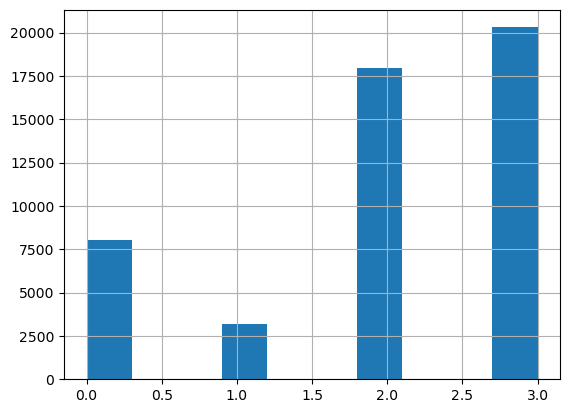

In [9]:
train['relevance'].hist()
print(round(train['relevance'].value_counts(normalize=True) * 100, 2))

In [10]:
test = pd.read_csv('test.csv')
test.head()

,id,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale
0,0,q_000000,#114114 mrs. kormel is not normal,p_0000000,Nature Made Melatonin 3 mg with 200 mg L-thean...,NaN,Contains a 613613-day supply of Nature Made Me...,Nature Made,Brown,us
1,1,q_000000,#2525 mrs. kormel is not normal,p_0000001,"My Weird School Special: Back to School, Weird...",<p>A My Weird School Special! </p> <p>Life is ...,NaN,brand_masked,NaN,us
2,2,q_000000,#759759 mrs. kormel is not normal,p_0000002,Liquid I.V. Hydration Multiplier - Lemon Lime ...,NaN,"Hydration Multiplier is a great-tasting, non-G...",Liquid I.V.,NaN,us
3,3,q_000000,#281281 mrs. kormel is not normal,p_0000003,"HARRIS Diatomaceous Earth Food Grade, 5lb with...",Harris Diatomaceous Earth Food Grade 176lb pow...,Natural Product - Composed of 890lbs of 890890...,HARRIS,NaN,us
4,4,q_000000,#250250 mrs. kormel is not normal,p_0000004,Retinol Complex Face Serum - 1oz from Naturium,This skin perfecting serum combines a potent c...,"ANTI-WRINKLE, MULTI-BENEFIT SERUM FOR FACE: Re...",Naturium,NaN,us


In [11]:
descriptive_statistics(test)

(21184, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21184 entries, 0 to 21183
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    21184 non-null  int64 
 1   query_id              21184 non-null  object
 2   query                 21184 non-null  object
 3   product_id            21184 non-null  object
 4   product_title         21184 non-null  object
 5   product_description   10294 non-null  object
 6   product_bullet_point  18188 non-null  object
 7   product_brand         19918 non-null  object
 8   product_color         14444 non-null  object
 9   product_locale        21184 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.6+ MB


None

,id
count,21184.000000
mean,35595.774500
std,20716.433346
min,0.000000
25%,16464.750000
50%,36725.500000
75%,53829.250000
max,70584.000000


,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale
count,21184,21184,21184,21184,10294,18188,19918,14444,21184
unique,1500,5103,20891,20793,9982,17333,9709,5190,1
top,q_002134,heres the skinny probiotic,p_0000130,Episode 1,This pre-owned or refurbished product has been...,Used Book in Good Condition,brand_masked,Black,us
freq,20,20,4,11,25,44,2065,2461,21184


id                      0
query_id                0
query                   0
product_id              0
product_title           0
product_description     0
product_bullet_point    0
product_brand           0
product_color           0
product_locale          0
dtype: object
id                          0
query_id                    0
query                       0
product_id                  0
product_title               0
product_description     10890
product_bullet_point     2996
product_brand            1266
product_color            6740
product_locale              0
dtype: int64


### Мы можем заключить, что:
- Пропуски содержаться в колонках `product_description`, `product_bullet_point`, `product_brand`, `product_color`
- Колонка `product_locale` не информативна, там только один признак, ее необходимо удалить
- Необходимо смотреть не только на NaN, пропуски могут закодированы быть по-другому. Например, в колонке `product_description` находится 'none' вместо NaN, что необходимо учесть при заполнении
- В тренировочном датасете преобладают релевантные запросы. Явно можем наблюдать сильный дисбаланс классов

count    3500.000000
mean       14.141714
std         2.427321
min        10.000000
25%        12.000000
50%        15.000000
75%        16.000000
max        20.000000
Name: product_id, dtype: float64


<Axes: >

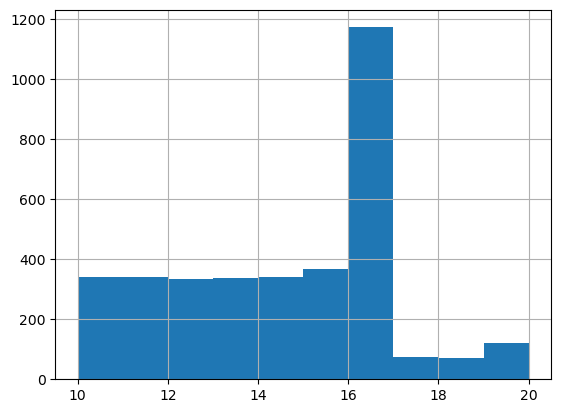

In [13]:
print(train.groupby("query_id")["product_id"].count().describe())
train.groupby("query_id")["product_id"].count().hist()

count    1500.000000
mean       14.122667
std         2.361215
min        10.000000
25%        12.000000
50%        15.000000
75%        16.000000
max        20.000000
Name: product_id, dtype: float64


<Axes: >

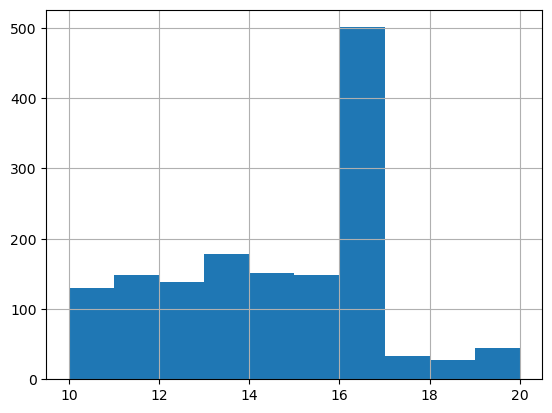

In [14]:
print(test.groupby("query_id")["product_id"].count().describe())
test.groupby("query_id")["product_id"].count().hist()

Распределение слегка скошено, однако количество запросов на каждый продукт находится строго в рамках 10-20, что хорошо для подсчета нашей метрики (тут все окей)

In [16]:
train["query_length"] = train["query"].str.split().str.len()
train["title_length"] = train["product_title"].str.split().str.len()
train["desc_length"]  = train["product_description"].fillna("").str.split().str.len()

train[["query_length", "title_length", "desc_length"]].describe()

,query_length,title_length,desc_length
count,49496.00000,49496.000000,49496.000000
mean,3.37500,20.444359,53.277113
std,1.51595,10.286820,74.860399
min,1.00000,1.000000,0.000000
25%,3.00000,12.000000,1.000000
50%,3.00000,19.000000,1.000000
75%,4.00000,28.000000,93.000000
max,23.00000,82.000000,517.000000


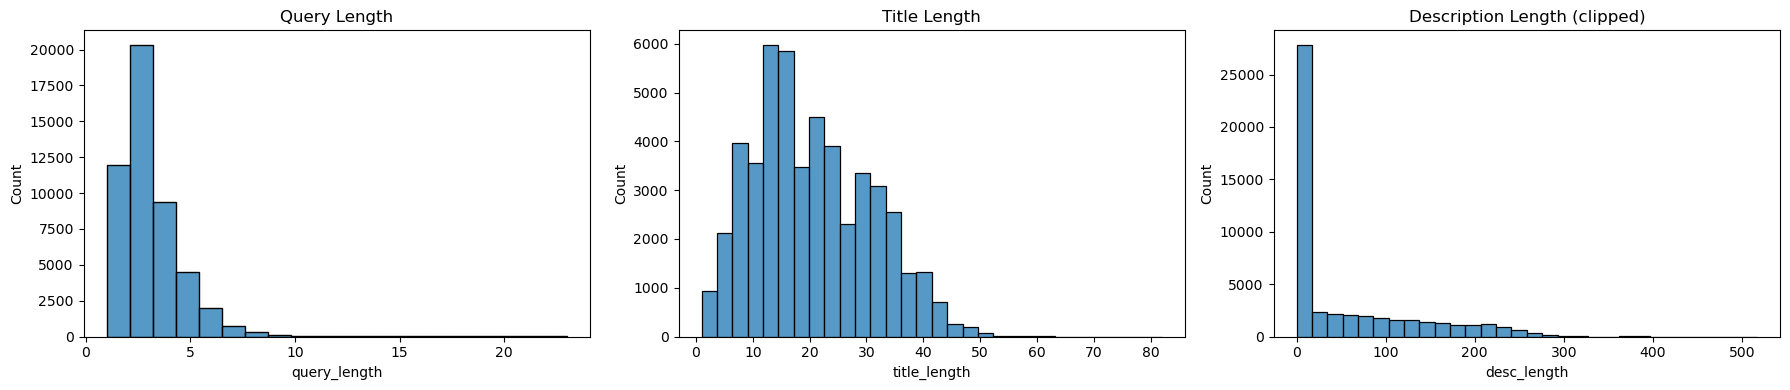

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(train["query_length"], bins=20, ax=axes[0])
axes[0].set_title("Query Length")

sns.histplot(train["title_length"], bins=30, ax=axes[1])
axes[1].set_title("Title Length")

sns.histplot(train["desc_length"], bins=30, ax=axes[2])
axes[2].set_title("Description Length (clipped)")

plt.tight_layout()
plt.show()

Запросы в среднем очень короткие — **3.4** слова, и 75% из них содержат не более 4 слов, что указывает на компактность и высокую концентрацию ключевых терминов. Названия товаров существенно длиннее: средняя длина **20** слов при максимуме 82, что делает title основным источником текстовой информации. Поле `description` крайне неоднородно: несмотря на среднее **53** слова, медиана равна **1** слову, что означает, что более половины описаний практически отсутствуют. В итоге для большинства товаров ключевую нагрузку несут именно `title`, а `descriptions` полезны только для небольшой части выборки.

In [19]:
def jaccard(a, b):
    a, b = set(a.lower().split()), set(b.lower().split())
    return len(a & b) / max(1, len(a | b))

train["q_t_overlap"] = train.apply(lambda x: jaccard(x["query"], x["product_title"]), axis=1)
train["q_t_overlap"].describe()


count    49496.000000
mean         0.070317
std          0.079003
min          0.000000
25%          0.000000
50%          0.055556
75%          0.100000
max          1.000000
Name: q_t_overlap, dtype: float64

Пересечение токенов между запросом и названием товара крайне низкое — среднее **0.07**, медиана **0.056**, и четверть выборки имеет пересечение 0, что говорит о слабом лексическом совпадении большинства пар `query–title`. Это означает, что простые модели, основанные на подсчёте совпадающих слов или BM25, будут давать ограниченный эффект и могут не раскрыть структуру релевантности. Поэтому в решении критично использовать модели, которые учитывают семантику, а не только лексические совпадения: *TF-IDF + dense модели*, *SBERT-эмбеддинги* 

## Data preparation

In [22]:
fill_map = {
    "product_description": "",
    "product_bullet_point": "",
    "product_brand": "unknown_brand",
    "product_color": "unknown_color",
    "product_title": ""
}
def fill_none(df):
    df = df.drop(columns=['product_locale'], errors='ignore')
    df['product_description'] = df['product_description'].replace('none', "")
    for col, val in fill_map.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

In [23]:
train = fill_none(train)

In [24]:
fill_none(test)
descriptive_statistics(train)

(49496, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49496 entries, 0 to 49495
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    49496 non-null  int64  
 1   query_id              49496 non-null  object 
 2   query                 49496 non-null  object 
 3   product_id            49496 non-null  object 
 4   product_title         49496 non-null  object 
 5   product_description   49496 non-null  object 
 6   product_bullet_point  49496 non-null  object 
 7   product_brand         49496 non-null  object 
 8   product_color         49496 non-null  object 
 9   relevance             49496 non-null  int64  
 10  query_length          49496 non-null  int64  
 11  title_length          49496 non-null  int64  
 12  desc_length           49496 non-null  int64  
 13  q_t_overlap           49496 non-null  float64
dtypes: float64(1), int64(5), object(8)
memory usage: 5.3+ MB


None

,id,relevance,query_length,title_length,desc_length,q_t_overlap
count,49496.000000,49496.000000,49496.00000,49496.000000,49496.000000,49496.000000
mean,35229.816005,2.021578,3.37500,20.444359,53.277113,0.070317
std,20267.602453,1.059737,1.51595,10.286820,74.860399,0.079003
min,27.000000,0.000000,1.00000,1.000000,0.000000,0.000000
25%,18207.750000,2.000000,3.00000,12.000000,1.000000,0.000000
50%,34636.500000,2.000000,3.00000,19.000000,1.000000,0.055556
75%,52630.250000,3.000000,4.00000,28.000000,93.000000,0.100000
max,70679.000000,3.000000,23.00000,82.000000,517.000000,1.000000


,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color
count,49496,49496,49496,49496,49496,49496,49496,49496
unique,3500,15921,48074,49327,24404,28352,18480,10962
top,q_003150,iphone 6 charger,p_0006462,episode 1,,,unknown_brand,unknown_color
freq,20,23,6,7,24980,19222,11982,15293


id                        0
query_id                  0
query                     0
product_id                0
product_title             0
product_description       0
product_bullet_point      0
product_brand             0
product_color             0
relevance                 0
query_length              0
title_length              0
desc_length               0
q_t_overlap             0.0
dtype: object
id                      0
query_id                0
query                   0
product_id              0
product_title           0
product_description     0
product_bullet_point    0
product_brand           0
product_color           0
relevance               0
query_length            0
title_length            0
desc_length             0
q_t_overlap             0
dtype: int64
relevance
3    20311
2    17969
0     8027
1     3189
Name: count, dtype: int64


In [25]:
test = fill_none(test)
descriptive_statistics(test)

(21184, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21184 entries, 0 to 21183
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    21184 non-null  int64 
 1   query_id              21184 non-null  object
 2   query                 21184 non-null  object
 3   product_id            21184 non-null  object
 4   product_title         21184 non-null  object
 5   product_description   21184 non-null  object
 6   product_bullet_point  21184 non-null  object
 7   product_brand         21184 non-null  object
 8   product_color         21184 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.5+ MB


None

,id
count,21184.000000
mean,35595.774500
std,20716.433346
min,0.000000
25%,16464.750000
50%,36725.500000
75%,53829.250000
max,70584.000000


,query_id,query,product_id,product_title,product_description,product_bullet_point,product_brand,product_color
count,21184,21184,21184,21184,21184,21184,21184,21184
unique,1500,5103,20891,20793,9983,17334,9710,5191
top,q_002134,heres the skinny probiotic,p_0000130,Episode 1,,,brand_masked,unknown_color
freq,20,20,4,11,10890,2996,2065,6740


id                      0
query_id                0
query                   0
product_id              0
product_title           0
product_description     0
product_bullet_point    0
product_brand           0
product_color           0
dtype: object
id                      0
query_id                0
query                   0
product_id              0
product_title           0
product_description     0
product_bullet_point    0
product_brand           0
product_color           0
dtype: int64
